In [21]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=",")
data.columns = ["Date", "Unemp"]  # adjust if names differ
data["Date"] = pd.to_datetime(data["Date"])
data = data[(data["Date"]>= "2006-01-01") & (data["Date"] <= "2023-01-01")]
data = data.set_index("Date").sort_index()


In [22]:
data

,Unemp
Date,
2006-01-01,12.1
2006-02-01,12.2
2006-03-01,12.0
2006-04-01,11.5
2006-05-01,10.9
...,...
2022-09-01,5.4
2022-10-01,5.3
2022-11-01,5.3


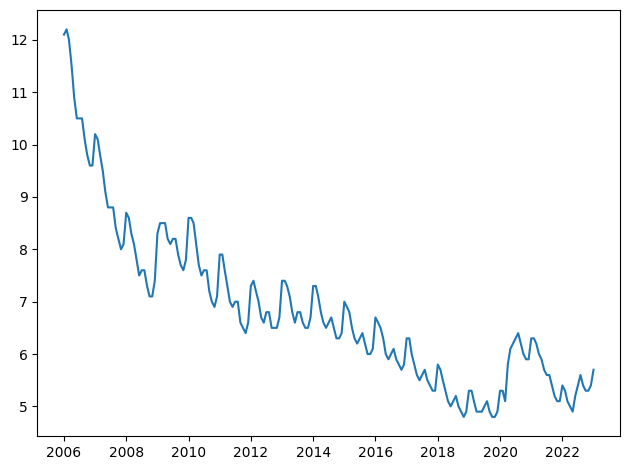

In [23]:
import matplotlib.pyplot as plt


plt.plot(data.index, data["Unemp"], label="Unemployment rate")

plt.tight_layout()
plt.show()


Unemp — lengths
level  raw n = 205
Δ1     raw n = 204
Δ12    raw n = 193


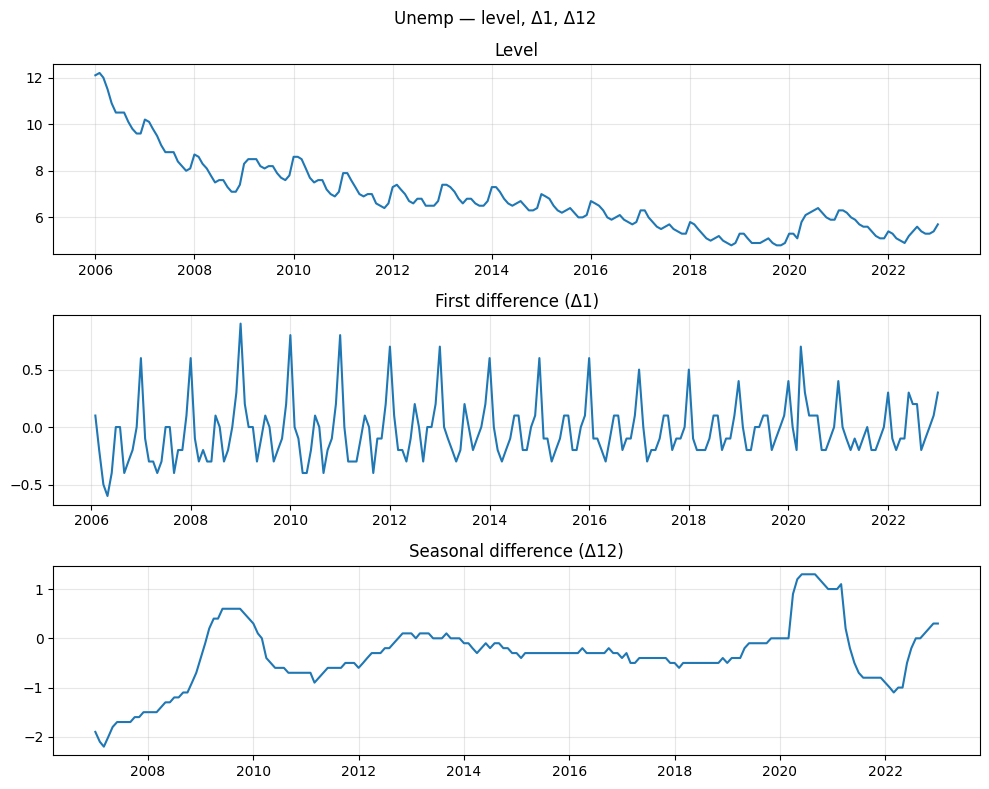

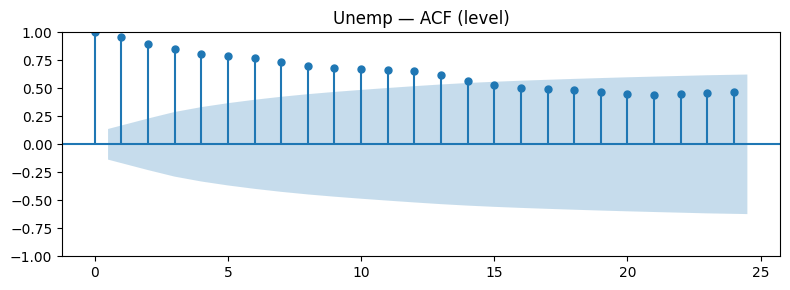

series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
 Unemp     level   n   -1.3950  0.1517        14       190       205    -2.5776    -1.9425     -1.6155        False        False         False
 Unemp     level   c   -2.0492  0.2654        14       190       205    -3.4652    -2.8769     -2.5749        False        False         False
 Unemp     level  ct   -2.8612  0.1754        14       190       205    -4.0072    -3.4339     -3.1408        False        False         False
 Unemp     diff1   n   -3.4621  0.0006        13       190       204    -2.5776    -1.9425     -1.6155         True         True          True
 Unemp     diff1   c   -3.5453  0.0069        13       190       204    -3.4652    -2.8769     -2.5749         True         True          True
 Unemp     diff1  ct   -3.6407  0.0266        13       190       204    -4.0072    -3.4339     -3.1408        False         True          True

In [27]:
# =========================
# Complete ADF test battery
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ----------------- Config -----------------
PLOT_SERIES = True      # set False to skip line plots
PLOT_ACF = True         # set False to skip ACF
ACF_MAXLAG = 24
MIN_LEN = 20            # minimum raw length to even attempt an ADF
MAXLAG = None           # None -> autolag="AIC"; else set an int (e.g., 12)
OUT_CSV = "adf_summary.csv"

# If your working DataFrame is 'panel_ecm', switch this:
# panel = panel_ecm

# ----------------- Helpers -----------------
def infer_seasonal_period(index) -> int | None:
    """
    Infer a sensible seasonal period m from a DatetimeIndex frequency.
    Returns 12 for monthly, 4 for quarterly, 7 for daily (weekly seasonality),
    52 for weekly, 365 for daily (yearly) if frequency suggests it; else None.
    """
    if not isinstance(index, pd.DatetimeIndex):
        return None

    # Use pandas' frequency inference if available
    freq = pd.infer_freq(index)
    if freq is None:
        # fallback: try heuristic by average steps
        diffs = pd.Series(index[1:] - index[:-1]).dt.days.dropna()
        if diffs.empty:
            return None
        step = int(round(diffs.median()))
        if step == 1:   # daily data
            return 7    # weekly seasonality as a pragmatic default
        return None

    f = freq.upper()

    # common cases
    if f.startswith("M"):   # month end/begin
        return 12
    if f.startswith("Q"):   # quarter end/begin
        return 4
    if f.startswith("W"):   # weekly
        return 52
    if f in ("D", "B"):     # daily or business daily
        return 7            # default to weekly cycle for daily data
    if f.startswith("H"):
        return 24
    return None

def adf_all(y: pd.Series,
            name: str,
            maxlag: int | None = None,
            min_len: int = 20,
            seasonal_period: int | None = None) -> pd.DataFrame:
    """
    Run ADF under regressions: 'nc', 'c', 'ct' on
    - level
    - first difference (Δ1)
    - seasonal difference (Δm) if m provided
    Returns a tidy DataFrame with stats, pvalues, used lag, obs counts, and critical values.
    """
    y = pd.Series(y, copy=False)
    cols = [
        "series","transform","reg",
        "adf_stat","pvalue",
        "used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    out = []

    def run_one(series, transform_label):
        series = pd.Series(series).dropna()
        nraw = int(series.shape[0])
        if nraw < min_len:
            for reg in ("nc","c","ct"):
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))
            return

        for reg in ("n","c","ct"):
            try:
                stat, p, usedlag, nobs, crit, icbest = adfuller(
                    series,
                    regression=reg,
                    autolag="AIC" if maxlag is None else None,
                    maxlag=maxlag
                )
                c1, c5, c10 = crit.get("1%"), crit.get("5%"), crit.get("10%")
                # ADF rejects if stat is MORE NEGATIVE than critical value
                r1 = bool((stat is not None) and (c1 is not None) and (stat < c1))
                r5 = bool((stat is not None) and (c5 is not None) and (stat < c5))
                r10 = bool((stat is not None) and (c10 is not None) and (stat < c10))
                out.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))
            except Exception:
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))

    # Level
    run_one(y, "level")
    # Δ1
    run_one(y.diff(), "diff1")
    # Δm (seasonal difference) if applicable
    if seasonal_period and seasonal_period >= 2:
        run_one(y.diff(seasonal_period), f"diff{seasonal_period}")

    return pd.DataFrame(out, columns=cols)

# ----------------- Main: per-column analysis -----------------
all_results = []
for col in data.columns:
    s = pd.to_numeric(data[col], errors="coerce")
    s_level = s.dropna()
    m = infer_seasonal_period(s.index)

    print("\n" + "="*80)
    print(f"{col} — lengths")
    print(f"level  raw n = {s_level.shape[0]}")
    print(f"Δ1     raw n = {s.diff().dropna().shape[0]}")
    if m:
        print(f"Δ{m:<5} raw n = {s.diff(m).dropna().shape[0]}")

    # Optional plots
    if PLOT_SERIES:
        fig, axes = plt.subplots(3 if m else 2, 1, figsize=(10, 8 if m else 6), sharex=False)
        fig.suptitle(f"{col} — level, Δ1" + (f", Δ{m}" if m else ""), y=0.98)
        # level
        if not s_level.empty:
            axes[0].plot(s_level.index, s_level.values)
        axes[0].set_title("Level")
        axes[0].grid(True, alpha=0.3)
        # Δ1
        d1 = s.diff().dropna()
        if not d1.empty:
            axes[1].plot(d1.index, d1.values)
        axes[1].set_title("First difference (Δ1)")
        axes[1].grid(True, alpha=0.3)
        # Δm
        if m:
            dm = s.diff(m).dropna()
            if not dm.empty:
                axes[2].plot(dm.index, dm.values)
            axes[2].set_title(f"Seasonal difference (Δ{m})")
            axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if PLOT_ACF:
        vals = s_level
        if len(vals) > ACF_MAXLAG:
            fig2, ax2 = plt.subplots(figsize=(8, 3))
            plot_acf(vals, ax=ax2, lags=ACF_MAXLAG)
            ax2.set_title(f"{col} — ACF (level)")
            plt.tight_layout()
            plt.show()

    # Run ADFs
    res = adf_all(
        s,
        name=col,
        maxlag=MAXLAG,
        min_len=MIN_LEN,
        seasonal_period=m
    )

    # Nice compact display for this series
    display_cols = [
        "series","transform","reg",
        "adf_stat","pvalue","used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res[display_cols].to_string(index=False))

    all_results.append(res)

# ----------------- Portfolio summary & export -----------------
adf_summary = pd.concat(all_results, ignore_index=True)

# convenience flags at 5%
adf_summary["reject_5pct_flag"] = adf_summary["reject_5pct"].astype(bool)

# What is stationary at level under ANY deterministic spec?
stationary_level_any = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].any()
               .reset_index(name="reject_at_level_any_spec_5pct")
)

# Robust (ALL specs reject at 5%) — stricter
stationary_level_all = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].all()
               .reset_index(name="reject_at_level_all_specs_5pct")
)

print("\n" + "-"*80)
print("Stationary at LEVEL (p<0.05) under ANY spec:")
print(stationary_level_any.to_string(index=False))
print("\nStationary at LEVEL (p<0.05) under ALL specs (strict):")
print(stationary_level_all.to_string(index=False))

# Best spec per transform by smallest p-value (for reporting)
best_by_p = (
    adf_summary
    .dropna(subset=["pvalue"])
    .sort_values(["series","transform","pvalue"], ascending=[True, True, True])
    .groupby(["series","transform"], as_index=False)
    .first()[["series","transform","reg","adf_stat","pvalue","used_lag","nobs_eff"]]
    .rename(columns={"reg":"best_reg_by_min_p"})
)
print("\nBest ADF (min p-value) per series x transform:")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(best_by_p.to_string(index=False))

# Save full tidy table
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results to: {OUT_CSV}")
